Accuracy: 1.0
              precision    recall  f1-score   support

Not Survived       1.00      1.00      1.00        53
    Survived       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Saved tree image.


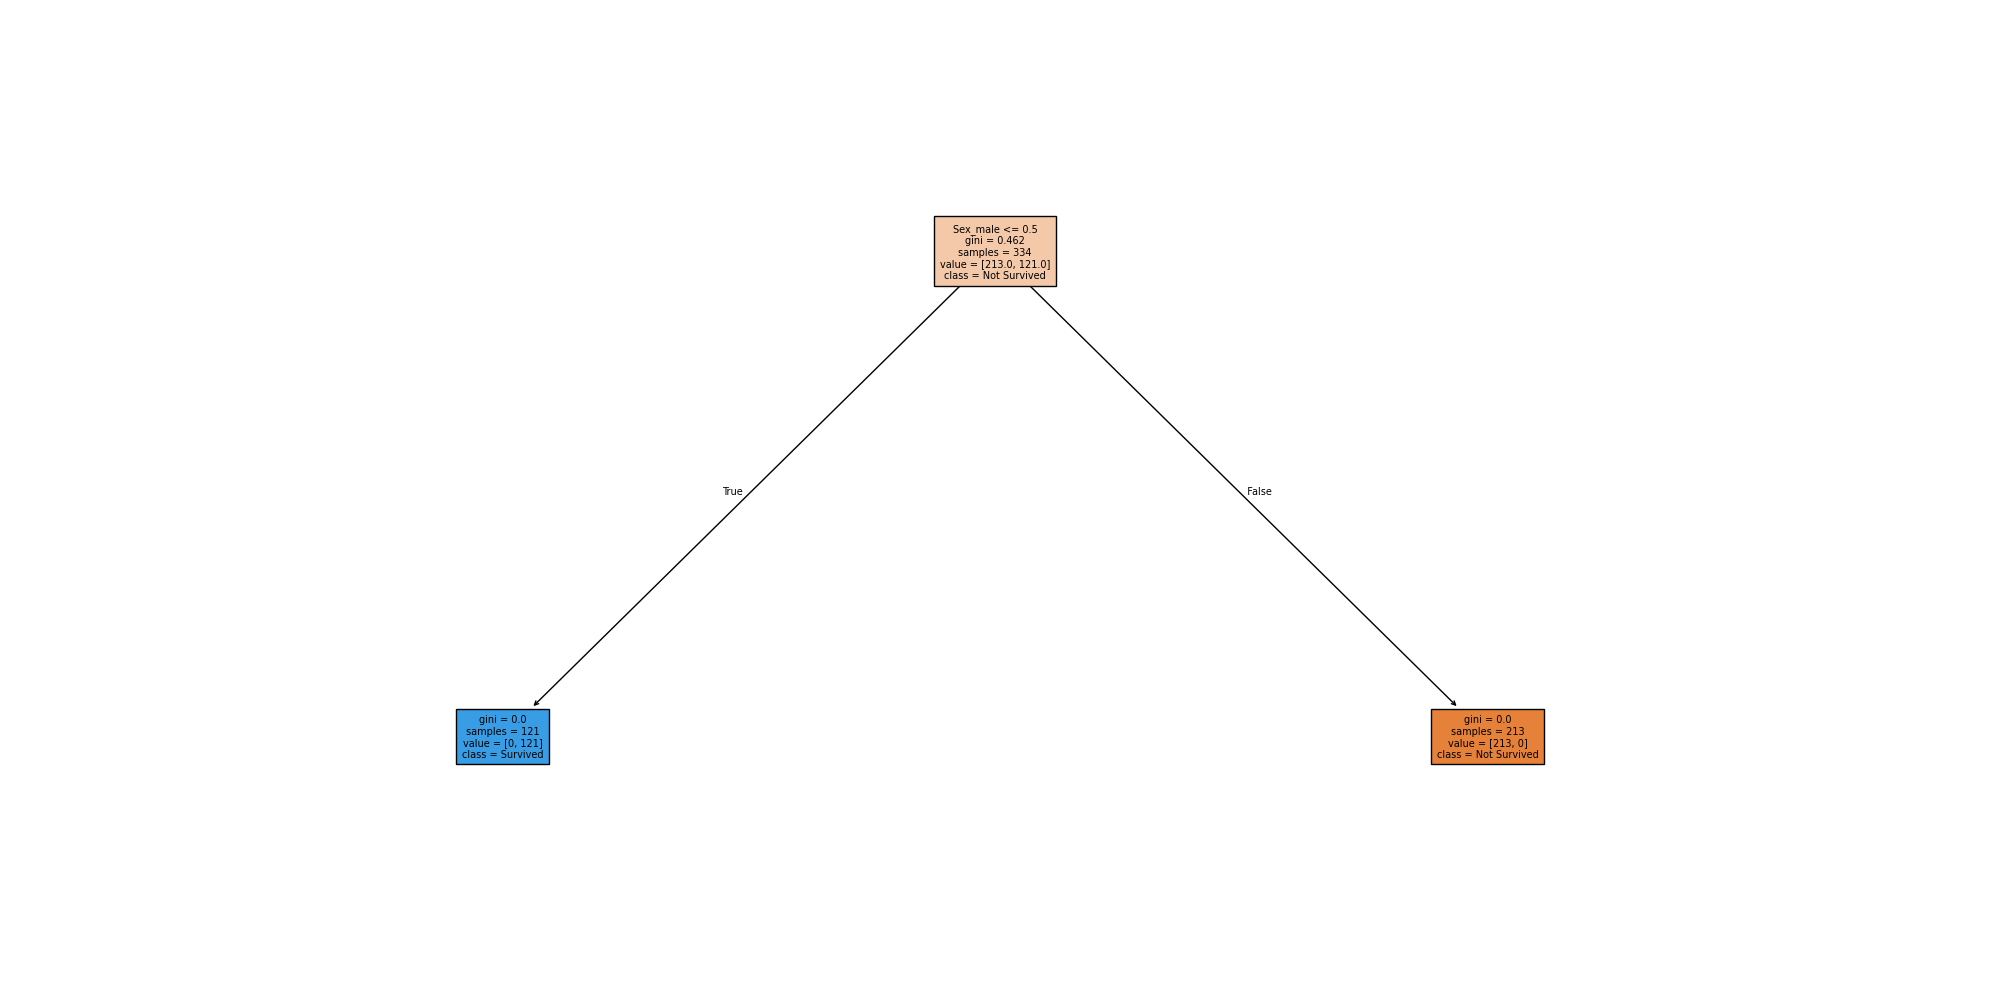

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/tested.csv')

# Fill missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Convert categorical columns into numerical values
df_encoded = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

# Select features and target
X = df_encoded.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin'])
y = df_encoded['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Decision Tree model
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Survived', 'Survived']
))

# Plot Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    fontsize=7
)

plt.tight_layout()

# Save tree image
plt.savefig('decision_tree.png', dpi=150)

print("Saved tree image.")